# Additional benchmark with CellRank

***

Jan T. Schleicher, 2025

We run [CellRank](https://cellrank.readthedocs.io/).
Specifically, we use the `VelocityKernel` to investigate the fate probabilities with CellRank based on a transition probability matrix obtained from RNA velocity.

In [1]:
import os

import cellrank as cr
import numpy as np
import pandas as pd
import scanpy as sc
from cellrank.kernels import VelocityKernel
from matplotlib import pyplot as plt

In [2]:
DATA_PATH = "../data/"

In [3]:
# Load processed AnnData object
adata = sc.read_h5ad(os.path.join(DATA_PATH, "tex_data_chronic_annotated.h5ad"))
adata

AnnData object with n_obs × n_vars = 13410 × 7170
    obs: 'sampleID', 'barcode', 'sample_type', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mitochondrial', 'log1p_total_counts_mitochondrial', 'pct_counts_mitochondrial', 'total_counts_ribosomal', 'log1p_total_counts_ribosomal', 'pct_counts_ribosomal', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_genes', 'n_counts', 'phase', 'S_score', 'G2M_score', 'score_diff', 'leiden', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'annot'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'mitochondrial', 'ribosomal', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'cell_cycle_genes', 'gene_count_corr', 'means', 'dispersions',

In [4]:
# Set up velocity kernel
velocity_kernel = VelocityKernel(adata)
velocity_kernel.compute_transition_matrix(model="stochastic")

  0%|          | 0/13410 [00:00<?, ?cell/s]

  0%|          | 0/13410 [00:00<?, ?cell/s]

VelocityKernel[n=13410, model='stochastic', similarity='correlation', softmax_scale=4.618]

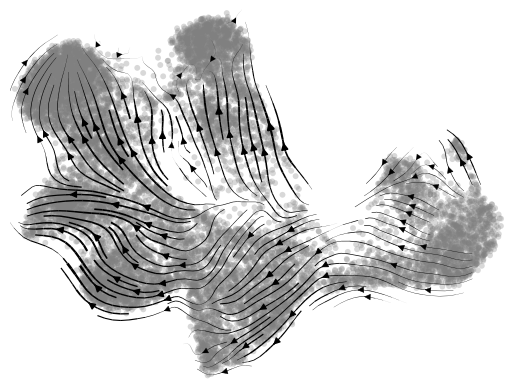

In [5]:
velocity_kernel.plot_projection()

  0%|          | 0/100 [00:00<?, ?sim/s]

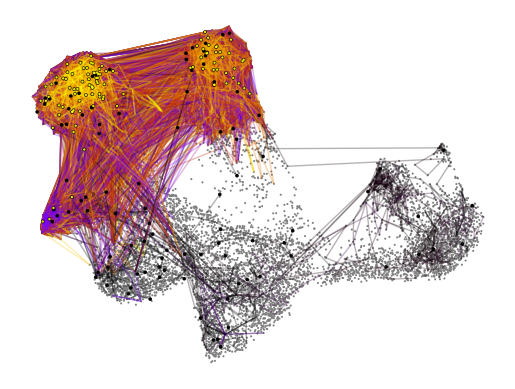

In [6]:
velocity_kernel.plot_random_walks()

/Users/janschleicher/miniconda3/envs/cytopath/lib/python3.9/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/Users/janschleicher/miniconda3/envs/cytopath/lib/python3.9/site-packages/scvelo/plotting/scatter.py:694: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/Users/janschleicher/miniconda3/envs/cytopath/lib/python3.9/site-packages/scvelo/plotting/utils.py:1396: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=bg_size, marker=".", c=bg_color, zorder=zord - 2, **kwargs)
/Users/janschleicher/miniconda3/envs/cytopath/lib/python3.9/site-packages/scvelo/plotting/utils.py:1397: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=gp_size, marker=".", c=gp_color, zorder=zord - 1, **kwargs)


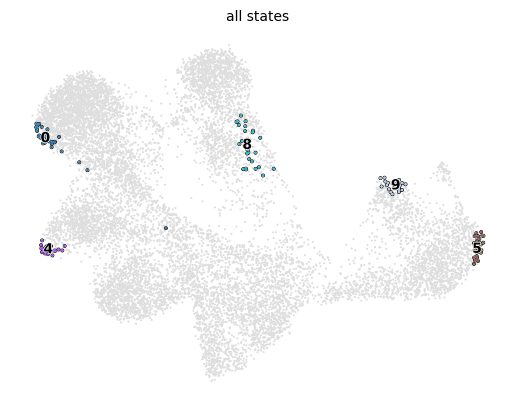

In [7]:
# Estimate terminal states
estimator_velocity = cr.estimators.GPCCA(velocity_kernel)
estimator_velocity.fit(cluster_key="leiden", n_states=[4, 20])
estimator_velocity.plot_macrostates(which="all")

  0%|          | 0/2 [00:00<?, ?/s]

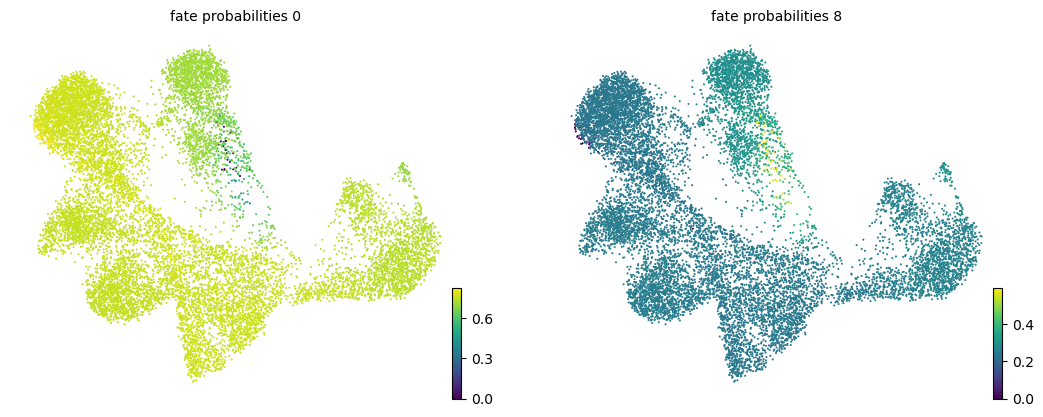

In [8]:
# Set terminal states and compute fate probabilities
estimator_velocity.set_terminal_states(states=["0", "8"])
estimator_velocity.compute_fate_probabilities()
estimator_velocity.plot_fate_probabilities(same_plot=False)

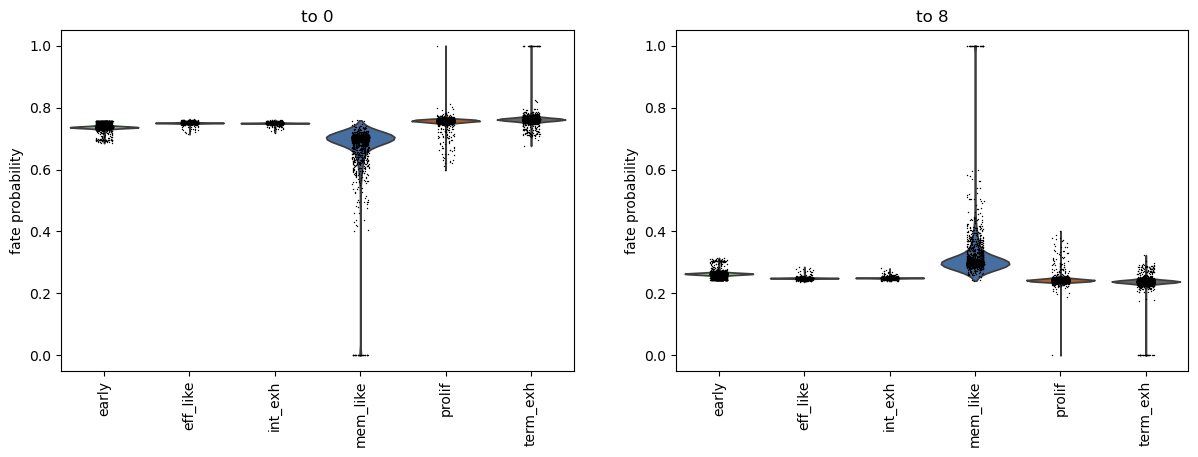

In [10]:
cr.pl.aggregate_fate_probabilities(
    adata, mode="violin", lineages=["0", "8"], cluster_key="annot"
)

In [11]:
# Write results
fate_probabilities_df = pd.DataFrame(
    data=estimator_velocity.fate_probabilities.tolist(),
    index=adata.obs_names,
    columns=estimator_velocity.fate_probabilities.names,
)
fate_probabilities_df.to_csv("../output/cellrank_fate_probabilities.csv")
velocity_kernel.write_to_adata()
adata.write_h5ad(
    os.path.join(DATA_PATH, "tex_data_chronic_cellrank.h5ad"), compression="gzip"
)

: 

: 

: 